In [1]:
import numpy as np
import pandas as pd
import re
import os
import sys
import glob
import matplotlib.pyplot as plt
from astropy.table import Table, join, vstack, hstack
from astropy.io import fits, ascii
import pickle
from PyAstronomy import pyasl
from time import sleep
from tqdm.notebook import tqdm
import warnings
import random
import scipy
import bottleneck as bn
warnings.filterwarnings("ignore")

In [2]:
# plotting parameters
plt.rc('axes', labelsize=12)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='5'
plt.rcParams['ytick.major.pad']='5'

#paper_params = {
#        #'text.usetex' : True,
#        'font.size'   : 10,
#        #'font.family' : 'lmodern',
#        'figure.dpi'  : 200
#        }
#plt.rcParams.update(paper_params)


In [3]:
def split_surf_file(surf_file):
    """
    from file string, extract
    model name,
    metallicity, 
    AGB mass
    inital mass
    final mass
    """
    model_name = surf_file.split('/')[-1][12:]
    metalZ = model_name.split('_')[-1][1:]
    AGB_mass = model_name.split('_')[-2][3:] #(model_name.split('_')[-2][3:4]+'.'+model_name.split('_')[-2][5:6])
    init_mass = (model_name.split('_')[0][1]+'.'+model_name.split('_')[0][3:5])
    final_mass = (model_name.split('_')[1][1]+'.'+model_name.split('_')[1][3:5])
    #if AGB_mass < init_mass: 
    #    return None
    return metalZ,AGB_mass,init_mass,final_mass

In [4]:
list_surf_files = np.genfromtxt('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/list_surface_files_full',dtype=str)
#print(len(list_surf_files))
# generate indicies
split = [split_surf_file(sf) for sf in list_surf_files if split_surf_file(sf) is not None]
# select unique indicies
unique = [list(np.unique(spl)) for spl in np.array(split).T]
print(len(unique[0]),len(unique[1]),len(unique[2]),len(unique[3]))

6 7 65 10


In [5]:
def create_delta(input_list):
    delta_list = []
    for i in range(len(input_list)-1):
        diff = (float(input_list[i+1]) - float(input_list[i])) / 2
        #print(i, diff)
        delta_list.append(diff)
    delta_list.insert(0,delta_list[0])

    return np.array(delta_list)

In [6]:
# convert unique values to floats to compute distances between grid points
# convert Z values to floats... 0.0001...
metal_Z = []
for z in unique[0]:
    capZ = np.log10(float('0.'+z)/0.0142)
    metal_Z.append(capZ)
metal_Z = np.array(metal_Z)
#metal_Z

# convert agb values to floats... 1p3 = 1.3
agb_masses = []
for m_agb in unique[1]:
    value = float(m_agb[0] + '.' + m_agb[-1])
    agb_masses.append(value)
agb_masses = np.array(agb_masses)
#agb_masses

# convert initial and final masses to floats from the unique array
initial_masses = []
for m_initial in unique[2]:
    value = float(m_initial)
    initial_masses.append(value)
initial_masses = np.array(initial_masses)
#initial_masses

final_masses = []
for m_final in unique[3]:
    value = float(m_final)
    final_masses.append(value)
final_masses = np.array(final_masses)
#final_masses

In [7]:
# create midpoint arrays / delta arrays for the grid...
delta_metal_Z = create_delta(metal_Z)
delta_m_agb = create_delta(agb_masses)
delta_m_init = create_delta(initial_masses)
delta_m_final = create_delta(final_masses)
delta_time = np.ones(30000)

In [8]:
#print('Reading MODEL grid from file: "model_grid_big_file.dat" and VALID file "valid_grid_big_file.dat"')
#with open('/data/beegfs/astro-storage/groups/rix/dimoff/BinaryStars/Accretion_New/model_grid_big_file.dat','rb') as file:
#MODEL = np.load('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/model_grid_big_file_full.dat')
#VALID = np.load('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/valid_grid_big_file_full.dat')
#print(np.shape(MODEL),np.shape(VALID))

In [9]:
print('Reading MODEL grid from file: "model_grid_full_size.dat" and VALID file "valid_grid_full_size.dat"')
#with open('/data/beegfs/astro-storage/groups/rix/dimoff/BinaryStars/Accretion_New/model_grid_big_file.dat','rb') as file:
MODEL = np.load('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/model_grid_full_size.dat')
VALID = np.load('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/valid_grid_full_size.dat')
print(np.shape(MODEL),np.shape(VALID))

Reading MODEL grid from file: "model_grid_big_file.dat" and VALID file "valid_grid_big_file.dat"
(6, 7, 65, 10, 30000, 20) (6, 7, 65, 10, 30000)


In [10]:
# generate priors based on size of grid cells
Del_Z, Del_magb, Del_mi, Del_mf, Del_t = np.meshgrid(delta_metal_Z,delta_m_agb,delta_m_init,delta_m_final,delta_time, indexing="ij")
# divide by sums for proper priors
top_prod = Del_magb * Del_mi * VALID
THETA = Del_Z/np.sum(Del_Z) * top_prod/(np.sum(top_prod)) * Del_mf/np.sum(Del_mf) * Del_t/np.sum(Del_t) 

In [11]:
print('Reading in observational data')
# read from the X_Fe_table from abundance infomation
Obs_Data_Table = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/X_Fe_table_3.dat',delimiter='&')
param_mass_table = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/param_mass_table.dat',format='latex')

full_obs_data_table = join(param_mass_table,Obs_Data_Table,keys='stars')
#print(full_obs_data_table)
cristallo_data = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/Cristallo_2016.dat')
goswami_2020_data = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/Gos_Rat_Gos_2020.dat')
goswami_2021_data = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/Gos_Rat_Gos_CEMPs_2021.dat')
DeCastro_Roriz = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/DeCastro_Roriz_Table.dat')
# stack them all up
#print(len(full_obs_data_table),len(cristallo_data),len(goswami_2020_data),len(goswami_2021_data),len(DeCastro_Roriz))
master_table = vstack([full_obs_data_table,cristallo_data,goswami_2020_data,goswami_2021_data,DeCastro_Roriz],join_type='inner')
obs_names = np.array(['C','C_sig','FeH','FeH_sig','Sr','Sr_sig','Y','Y_sig','Zr','Zr_sig','Nb','Nb_sig','Mo','Mo_sig','Ru','Ru_sig','Ba','Ba_sig','La','La_sig','Ce','Ce_sig','Pr','Pr_sig','Nd','Nd_sig','Sm','Sm_sig','Eu','Eu_sig','Dy','Dy_sig','Pb','Pb_sig'])
len(master_table)

Reading in observational data


283

In [12]:
## Average Uncertainties across the samples
#print('Cristallo',np.nanmedian([cristallo_data['C_sig'],cristallo_data['Sr_sig'],cristallo_data['Y_sig'],cristallo_data['Zr_sig'],cristallo_data['Nb_sig'],cristallo_data['Mo_sig'],cristallo_data['Ru_sig'],cristallo_data['Ba_sig'],cristallo_data['La_sig'],cristallo_data['Ce_sig'],cristallo_data['Pr_sig'],cristallo_data['Nd_sig'],cristallo_data['Sm_sig'],cristallo_data['Eu_sig'],cristallo_data['Pb_sig']]))
#print('Goswami',np.nanmedian([goswami_2021_data['C_sig'],goswami_2021_data['Sr_sig'],goswami_2021_data['Y_sig'],goswami_2021_data['Zr_sig'],goswami_2021_data['Nb_sig'],goswami_2021_data['Mo_sig'],goswami_2021_data['Ru_sig'],goswami_2021_data['Ba_sig'],goswami_2021_data['La_sig'],goswami_2021_data['Ce_sig'],goswami_2021_data['Pr_sig'],goswami_2021_data['Nd_sig'],goswami_2021_data['Sm_sig'],goswami_2021_data['Eu_sig'],goswami_2021_data['Pb_sig']]))
#print('DeC_Ror',np.nanmedian([DeCastro_Roriz['C_sig'],DeCastro_Roriz['Sr_sig'],DeCastro_Roriz['Y_sig'],DeCastro_Roriz['Zr_sig'],DeCastro_Roriz['Nb_sig'],DeCastro_Roriz['Mo_sig'],DeCastro_Roriz['Ru_sig'],DeCastro_Roriz['Ba_sig'],DeCastro_Roriz['La_sig'],DeCastro_Roriz['Ce_sig'],DeCastro_Roriz['Pr_sig'],DeCastro_Roriz['Nd_sig'],DeCastro_Roriz['Sm_sig'],DeCastro_Roriz['Eu_sig'],DeCastro_Roriz['Pb_sig']]))
#print('Dimoff',np.nanmedian([full_obs_data_table['C_sig'],full_obs_data_table['Sr_sig'],full_obs_data_table['Y_sig'],full_obs_data_table['Zr_sig'],full_obs_data_table['Nb_sig'],full_obs_data_table['Mo_sig'],full_obs_data_table['Ru_sig'],full_obs_data_table['Ba_sig'],full_obs_data_table['La_sig'],full_obs_data_table['Ce_sig'],full_obs_data_table['Pr_sig'],full_obs_data_table['Nd_sig'],full_obs_data_table['Sm_sig'],full_obs_data_table['Eu_sig'],full_obs_data_table['Pb_sig']]))

Text(0.5, 0, 'Teff')

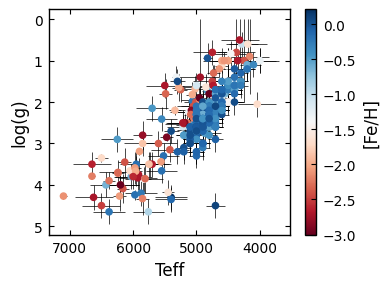

In [13]:
fig, ax = plt.subplots(ncols=1,sharey=True,figsize=(4,3),tight_layout=True)
ax.errorbar(master_table['Teff'], master_table['logg'], xerr=master_table['e_Teff'], yerr=master_table['e_logg'],color='black',elinewidth=0.5,markersize=0,ls='')
scat = ax.scatter(master_table['Teff'], master_table['logg'],c=master_table['FeH'],s=20,cmap='RdBu',zorder=2)
ax.invert_yaxis()
ax.invert_xaxis()
fig.colorbar(scat,label='[Fe/H]')
ax.set_ylabel('log(g)')
ax.set_xlabel('Teff')
#plt.savefig('sample_keil_diagram_metallicities.png',dpi=200,bbox_inches=None)

In [14]:
def get_star_params(table_in_question, star_index):
    star_name = table_in_question['stars'][star_index]
        
    obs_data = [table_in_question['C'][star_index],   table_in_question['C_sig'][star_index],   # C
                table_in_question['FeH'][star_index], table_in_question['FeH_sig'][star_index], # (Fe)
                table_in_question['Sr'][star_index],  table_in_question['Sr_sig'][star_index],  # Sr
                table_in_question['Y'][star_index],   table_in_question['Y_sig'][star_index],   # Y
                table_in_question['Zr'][star_index],  table_in_question['Zr_sig'][star_index],  # Zr
                table_in_question['Nb'][star_index],  table_in_question['Nb_sig'][star_index],  # Nb
                table_in_question['Mo'][star_index],  table_in_question['Mo_sig'][star_index],  # Mo
                table_in_question['Ru'][star_index],  table_in_question['Ru_sig'][star_index],  # Ru
                table_in_question['Ba'][star_index],  table_in_question['Ba_sig'][star_index],  # Ba
                table_in_question['La'][star_index],  table_in_question['La_sig'][star_index],  # La
                table_in_question['Ce'][star_index],  table_in_question['Ce_sig'][star_index],  # Ce
                table_in_question['Pr'][star_index],  table_in_question['Pr_sig'][star_index],  # Pr
                table_in_question['Nd'][star_index],  table_in_question['Nd_sig'][star_index],  # Nd
                table_in_question['Sm'][star_index],  table_in_question['Sm_sig'][star_index],  # Sm
                table_in_question['Eu'][star_index],  table_in_question['Eu_sig'][star_index],  # Eu
                table_in_question['Dy'][star_index],  table_in_question['Dy_sig'][star_index],  # Dy
                table_in_question['Pb'][star_index],  table_in_question['Pb_sig'][star_index]]  # Pb
    
    # surface parameters
    logg = table_in_question['logg'][star_index]
    e_logg = table_in_question['e_logg'][star_index]
    gstar = 10**logg; e_gstar = 10**(logg-e_logg)
    Teff = table_in_question['Teff'][star_index]
    e_Teff = table_in_question['e_Teff'][star_index]
    log_Teff = np.log10(Teff); log_e_Teff = (e_Teff**2/(Teff*np.log10(e_Teff))**2)**(1/2)
    FeH = table_in_question['FeH'][star_index]
    eFeH = table_in_question['FeH_sig'][star_index]

# -------------------------------
    # add a flag for classification purposes
    flag = 'empty'
    # identify elemental groups for classification purposes
    ls = bn.nanmean([table_in_question['Sr'][star_index],table_in_question['Y'][star_index],
                     table_in_question['Zr'][star_index]])#, table_in_question['Nb'][star_index]
                     #table_in_question['Mo'][star_index]])#,table_in_question['Ru'][star_index]])
    hs = bn.nanmean([table_in_question['Ba'][star_index],table_in_question['La'][star_index],
                     table_in_question['Ce'][star_index],#table_in_question['Pr'][star_index],
                     table_in_question['Nd'][star_index]])    

    C_enhanced = table_in_question['C'][star_index] > 0.50 # or 0.70? # or 0.50?
    Metal_Poor = table_in_question['FeH'][star_index] < -1.00

    dash_s = (hs - table_in_question['Eu'][star_index] > 0.50) and hs > 0.90 ## Beers + Christlieb 2005 / Jorissen 2016
    #dash_s = (hs > 1.00) and (hs - table_in_question['Eu'][star_index] > 0.50) ## Sivarani 2006
    #dash_s = (hs > 1.00) and (hs - table_in_question['Eu'][star_index] > 0.00) and (table_in_question['Eu'][star_index] < 1.00) ## Jonsell 2006
    #dash_s = (hs - table_in_question['Eu'][star_index] > 0.00) and hs > 0.90 ## Abate 2016
    
    dash_rs = (hs - table_in_question['Eu'][star_index] < 0.50) and (hs - table_in_question['Eu'][star_index] > 0.10) ## Beers + Christlieb 2005 / Jorissen 2016
    #dash_rs = (hs > 0.0) and (hs < 0.50) ## Sivarani 2006
    #dash_rs = (table_in_question['Eu'][star_index] > 1.00) and (hs > 1.00) and (hs - table_in_question['Eu'][star_index] > 0.0) ## Abate 2016
    #dash_rs = (table_in_question['Eu'][star_index] > 1.00) and (hs - table_in_question['Eu'][star_index] > 0.0) and (hs - table_in_question['Eu'][star_index] < 1.0) ## Hansen 2019
    
    #dash_r = table_in_question['Eu'][star_index] > 1.00 ## Beers + Christlieb 2005
    dash_r = table_in_question['Eu'][star_index] > 1.00 and hs < 0.0 ## Abate 2016
    
    ## CEMP: [C/Fe] ≥ 0.7
    ## CEMP-r/s: [Ba/Fe] ≥ 1.0, [Eu/Fe] ≥ 1.0
    ## i) 0.0 ≤ [Ba/Eu] ≤ 1.0 and/or 0.0 ≤ [La/Eu] ≤ 0.7;
    ## CEMP-s: [Ba/Fe] ≥ 1.0
    ## i.) [Eu/Fe] < 1.0, [Ba/Eu] > 0.0 and/or [La/Eu] > 0.5;
    ## ii.) [Eu/Fe] ≥ 1.0, [Ba/Eu] > 1.0 and/or [La/Eu] > 0.7.
    
    ## CAMILLA'S CRITERION BASED ON SR AND BA -- LS AND HS
    #CEMP-no [Sr/Ba] > 0.75 New classification
    #if C_enhanced and Metal_Poor and (ls - hs > 0.75): # Hansen 2019
    #    flag = 'CEMP-no'
    #if C_enhanced and Metal_Poor and hs < 0.0: # Beers + Christlieb 2005 / Jorissen 2016
    #    flag = 'CEMP-no'
    ## THE ORDER OF THESE MATTERS
    #if C_enhanced and Metal_Poor and (ls < -1.5): # Hansen 2019
    #    flag = 'CEMP-r'
    #if C_enhanced and Metal_Poor and dash_r: 
    #    flag = 'CEMP-r'
    if C_enhanced and Metal_Poor and (ls - hs > -0.60) and (ls - hs < 0.60): # Hansen 2019
        flag = 'CEMP-s'
    #elif C_enhanced and Metal_Poor and (ls - hs > -1.5) and (ls - hs > -0.5): # Hansen 2019
    #    flag = 'CEMP-r/s'
    elif C_enhanced and Metal_Poor and dash_rs: 
        flag = 'CEMP-r/s'
    elif C_enhanced and Metal_Poor and dash_s: 
        flag = 'CEMP-s'

    ## add flag for CH stars as those at higher metallicities but share same characteristics
    elif Metal_Poor and C_enhanced: # ...? These stars are metal poor, but not SO carbon enriched... this is tough, some could be r/s?
        flag = 'CH'
    
    # Escorza's strong / weak Ba star criterion:
    elif not Metal_Poor and ls > 0.2 or hs > 0.2 and not C_enhanced:
        if ls > 0.8 or hs > 0.8:
            flag = 'SBa'
        elif (ls > 0.2 and ls < 0.8) or (hs > 0.2 and hs < 0.8):
            flag = 'WBa'
# -------------------------------
    ## assign masses based on observations
    ## or from previous population studies
    for col_name in table_in_question.columns:
        if col_name == 'vis':   
            m_star = table_in_question['vis'][star_index]
            e_m_star = table_in_question['e_vis'][star_index]
        # for tagged Barium stars, avg mass is ~2.50
        elif flag == 'WBa' or flag == 'SBa':
            m_star = np.nan # 2.50
            e_m_star = np.nan # 1.00
        # CEMP stars, avg mass is ~0.80
        elif flag == 'CEMP-s' or flag == 'CEMP-r/s' or flag == 'CH':
            m_star = np.nan # 0.80
            e_m_star = np.nan # 1.00
        # if not, give it a nan
        else:
            m_star = np.nan #1.50
            e_m_star = np.nan #1.50
# -------------------------------
    # element names (skip errors in names list)
    obs_names_I_ = obs_names[0:-1:2]
    obs_elems_nums = [6,38,39,40,41,42,44,56,57,58,59,60,62,63,66,82]    
    # observed abundances and errors go into obs_data array
    obs_elems = obs_data[0:-1:2]
    obs_errrs = obs_data[1::2]

    # collect observational data and uncertanties in arrays
    # skip Fe (index 1) in these lists...
    obs_names_II = []
    obs_elems_II = []
    obs_errrs_II = []
    for i in range(len(obs_elems)): 
        if i != 1:
            obs_names_II.append(obs_names_I_[i])
            obs_elems_II.append(obs_elems[i])
            obs_errrs_II.append(obs_errrs[i])
    
    #print('Collect observational data for the star in an array')
    X_obs = np.concatenate([[FeH,log_Teff,logg,m_star],obs_elems_II])
    X_sig = np.concatenate([[eFeH,log_e_Teff,e_logg,e_m_star],obs_errrs_II])
            
    return star_name, obs_names_II, obs_elems_nums, obs_elems_II, obs_errrs_II, X_obs, X_sig, flag

In [15]:
# apply flags... how many are in each category? - we do have some overlaps...
# total Ba stars should be ~190-something
# CEMP should be around 76 (42 -s and 36 -r/s)
# CH should be around 27
Cs_flgs = []
Cr_flgs = []
Crs_flgs = []
Cno_flgs = []
CH_flgs = []
WBa_flgs = []
SBa_flgs = []
empty_flgs = []
for indx in range(len(master_table)):
    #if indx == 106:
    star_name, obs_names_II, obs_elems_nums, obs_elems_II, obs_errrs_II, X_obs, X_sig, type_flag = get_star_params(master_table,indx)
    #print(star_name, type_flag)
    if type_flag == 'CEMP-s':
        Cs_flgs.append(type_flag)
    elif type_flag == 'CEMP-r':
        Cr_flgs.append(type_flag)
    elif type_flag == 'CEMP-r/s':
        Crs_flgs.append(type_flag)
    elif type_flag == 'CEMP-no':
        Cno_flgs.append(type_flag)
    elif type_flag == 'CH':
        CH_flgs.append(type_flag)
    elif type_flag == 'WBa':
        WBa_flgs.append(type_flag)
    elif type_flag =='SBa':
        SBa_flgs.append(type_flag)
    elif type_flag == 'empty':
        empty_flgs.append(type_flag)
print(len(Cs_flgs),len(Crs_flgs),len(Cr_flgs),len(Cno_flgs),len(WBa_flgs),len(SBa_flgs),len(CH_flgs),len(empty_flgs))

40 23 0 0 88 105 21 6


In [16]:
# Function to calculate statistics for each parameter
def get_stats(values, weights):
    # Normalize weights
    weights = weights / np.sum(weights)
    
    # Calculate mean
    mean = np.sum(values * weights)
    
    # Calculate median (50th percentile)
    cumsum = np.cumsum(weights[np.argsort(values)])
    median = values[np.argsort(values)][np.searchsorted(cumsum, 0.5)]
    
    # Calculate 16th and 84th percentiles (68% confidence interval)
    p16 = values[np.argsort(values)][np.searchsorted(cumsum, 0.16)]
    p84 = values[np.argsort(values)][np.searchsorted(cumsum, 0.84)]
    
    return mean, median, p16, p84


In [17]:
def write_parameter_stats(star_name, metal_Z, agb_masses, initial_masses, final_masses, 
                         prob_Z, prob_magb, prob_mi, prob_mf,
                         metal_stats, agb_stats, mi_stats, mf_stats):
    
    stats_dir = '/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/statistics_mass_limit_weights'
    
    # Create output filename in statistics directory
    outfile = os.path.join(stats_dir, f'parameter_stats_{star_name}.txt')
        
    with open(outfile, 'w') as f:
        f.write(f'Parameter Statistics for {star_name}\n')
        f.write('=' * 50 + '\n\n')
        
        # Write metallicity stats
        f.write('Metallicity [Fe/H]\n')
        f.write('-' * 20 + '\n')
        f.write(f'Mean: {metal_stats[0]:.3f}\n')
        f.write(f'Median: {metal_stats[1]:.3f}\n')
        f.write(f'68% confidence interval: [{metal_stats[2]:.3f}, {metal_stats[3]:.3f}]\n')
        f.write('Probability distribution:\n')
        for z, p in zip(metal_Z, prob_Z):
            f.write(f'{z:.3f}: {p:.3e}\n')
        f.write('\n')
        
        # Write AGB mass stats  
        f.write('AGB Mass (M⊙)\n')
        f.write('-' * 20 + '\n')
        f.write(f'Mean: {agb_stats[0]:.3f}\n')
        f.write(f'Median: {agb_stats[1]:.3f}\n')
        f.write(f'68% confidence interval: [{agb_stats[2]:.3f}, {agb_stats[3]:.3f}]\n')
        f.write('Probability distribution:\n')
        for m, p in zip(agb_masses, prob_magb):
            f.write(f'{m:.3f}: {p:.3e}\n')
        f.write('\n')
        
        # Write initial mass stats
        f.write('Initial Mass (M⊙)\n') 
        f.write('-' * 20 + '\n')
        f.write(f'Mean: {mi_stats[0]:.3f}\n')
        f.write(f'Median: {mi_stats[1]:.3f}\n')
        f.write(f'68% confidence interval: [{mi_stats[2]:.3f}, {mi_stats[3]:.3f}]\n')
        f.write('Probability distribution:\n')
        for m, p in zip(initial_masses, prob_mi):
            f.write(f'{m:.3f}: {p:.3e}\n')
        f.write('\n')
        
        # Write final mass stats
        f.write('Final Mass (M⊙)\n')
        f.write('-' * 20 + '\n') 
        f.write(f'Mean: {mf_stats[0]:.3f}\n')
        f.write(f'Median: {mf_stats[1]:.3f}\n')
        f.write(f'68% confidence interval: [{mf_stats[2]:.3f}, {mf_stats[3]:.3f}]\n')
        f.write('Probability distribution:\n')
        for m, p in zip(final_masses, prob_mf):
            f.write(f'{m:.3f}: {p:.3e}\n')


In [ ]:
def compute_chi_sq(star_index):
    
    star_name, obs_names_II, obs_elems_nums, obs_elems_II, obs_errrs_II, X_obs, X_sig, type_flag = get_star_params(master_table, star_index)
    
    #print(star_name, X_obs)
    len_nans = 0
    for obs in X_obs:
        if np.isnan(obs):
            #print('nan')
            len_nans += 1
    #print(len_nans)
    non_nan_obs_length = len(X_obs) - len_nans
    #print(non_nan_obs_length)
    
    for i,(sig,data) in enumerate(zip(X_sig,X_obs)):
        #print(i,data,sig)
        if (np.isnan(sig) and not(np.isnan(data))):
            #print(i,data,sig)
            X_sig[i] = X_obs[i] / 2
            X_obs[i] = 0.00
    #print(X_obs)        

    ## constrain by metallicity, apply prior
    ## limit the searched parameter space by metallicities close to the observations
    arr_metal = [-2.1522884,  -1.6751671,  -1.1522883,  -0.6751671,  -0.3741371,  -0.15228835] #unique[0]    
    if X_obs[0] < arr_metal[0]:
        metal_VALID = np.array([True, True, False, False, False, False])
    else:
        metal_VALID = (np.abs(arr_metal - X_obs[0]) < 3.0 * X_sig[0])
    # reset valid array with compatible metallicities
    new_VALID = metal_VALID[:, None, None, None, None] * VALID
    
    # sub sample of the model array for speed. take every n_th model from each evolutionary track, at least every other model should be close enough for a zoom in...? -- not always the case...
    new_spacing = 1 
    subsample_MODEL = MODEL[:,:,:,:,::new_spacing,:]
    subsample_VALID = new_VALID[:,:,:,:,::new_spacing]
    subsample_THETA = THETA[:,:,:,:,::new_spacing]
    
    subsample_Del_Z = Del_Z[:,:,:,:,::new_spacing]
    subsample_Del_magb = Del_magb[:,:,:,:,::new_spacing]
    subsample_Del_mi = Del_mi[:,:,:,:,::new_spacing]
    subsample_Del_mf = Del_mf[:,:,:,:,::new_spacing]
    #print('sub_theta',np.shape(subsample_THETA))

    ## apply weights to the residuals for the surface parameters such that they are more important...
    weights = [3./non_nan_obs_length,3./non_nan_obs_length,3./non_nan_obs_length,1.0,
               1.5,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0]
    print('Compute squared residuals between observational data and grid of models')
    #print(-np.square( (subsample_MODEL - X_obs) / (X_sig*weights) ) / (X_sig*weights))
    residuals_sq = np.square( (subsample_MODEL - X_obs) / (X_sig*weights) )
    #print(np.shape(residuals_sq))

    print('Compute chi_squared value by summing up all residuals')
    chi_sq = bn.nansum(residuals_sq,axis=-1) ## use bottleneck nansum here to sum up residuals for the chi_sq
    chi_sq[np.invert(subsample_VALID)] = np.inf ## change non-valid answers to infinities
    
    #print(np.shape(chi_sq))
    # save chi_sqs to file...
    with open('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/chi_sq_info/'+str(star_name)+'_rough_chis_weights.npy','wb') as chisq_handler:
        np.save(chisq_handler,chi_sq)

    # sort best indices by chi sq
    best_inds_all = np.array(np.unravel_index(np.argsort(chi_sq,axis=None),chi_sq.shape,order='C')).T
    print('best track and model via chi sq',best_inds_all[0])

    print('Compute likelihood and probability value')
    chi_sq_normalized = chi_sq - np.nanmin(chi_sq)
    log_like = -chi_sq_normalized ## compute log likelihood from chi sq
    #max_log_like = np.nanmax(log_like)
    like = np.exp(log_like) # - max_log_like) ## compute likelihood from log likelihood
    #print(np.shape(like))
    like_norm = like / np.nansum(like) ## normalize likelihood to sum to 1

    # combine likelihood with priors
    #prob = bn.nansum(like) * subsample_THETA / np.sum(subsample_THETA)
    log_THETA = np.log(subsample_THETA)
    prob = like_norm * np.exp(log_THETA - np.log(np.nansum(subsample_THETA))) ## compute probability from likelihood and priors

    # sort best indices by probability
    # and check if probability and chi find same best model
    best_inds_all_prob = np.array(np.unravel_index(np.argsort(-prob,axis=None),prob.shape,order='C')).T
    print('best track and model via likelihood',best_inds_all_prob[0])

    probs = [] # np.zeros(max_results)
    chis = [] #  np.zeros(max_results)
    models = [] # np.zeros(max_results, dtype=int)
    tracks = [] # np.zeros((max_results, 4), dtype=int)

    for ind in best_inds_all:
        if prob[tuple(ind)] > 0.0 and chi_sq[tuple(ind)] < np.inf:
            probs.append(prob[tuple(ind)])
            chis.append(chi_sq[tuple(ind)])
            models.append(ind[-1]*new_spacing)
            tracks.append(ind[0:-1])
            
    probs = np.array(probs)
    chis = np.array(chis)
    models = np.array(models)
    tracks = np.array(tracks)
    
    # compute probabilities for each parameter :: Marginalize over all other parameters to get probability distribution
    prob_Z    = np.sum(np.sum(np.sum(np.sum(like, axis=4), axis=3), axis=2), axis=1) * subsample_Del_Z[:,0,0,0,0] / np.sum(subsample_Del_Z)
    prob_magb = np.sum(np.sum(np.sum(np.sum(like, axis=4), axis=3), axis=2), axis=0) * subsample_Del_magb[0,:,0,0,0] / np.sum(subsample_Del_magb)
    prob_mi   = np.sum(np.sum(np.sum(np.sum(like, axis=4), axis=3), axis=1), axis=0) * subsample_Del_mi[0,0,:,0,0] / np.sum(subsample_Del_mi)
    prob_mf   = np.sum(np.sum(np.sum(np.sum(like, axis=4), axis=2), axis=1), axis=0) * subsample_Del_mf[0,0,0,:,0] / np.sum(subsample_Del_mf)

    # Calculate statistics for each parameter
    metal_stats = get_stats(metal_Z, prob_Z)
    agb_stats = get_stats(agb_masses, prob_magb)
    mi_stats = get_stats(initial_masses, prob_mi)
    mf_stats = get_stats(final_masses, prob_mf)
    
    write_parameter_stats(star_name, metal_Z, agb_masses, initial_masses, final_masses,
                     prob_Z, prob_magb, prob_mi, prob_mf,
                     metal_stats, agb_stats, mi_stats, mf_stats)

    #plot likelihood, prior, posterior distributions
    #fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 5), sharex=True)
    #ax.plot(metal_Z, prob_Z, label='Likelihood', color='blue')
    #ax.set_ylabel('Probability')
    #ax.plot(metal_Z, subsample_THETA[:,0,0,0,0], label='Prior', color='orange')
    #ax.plot(metal_Z, prob_Z * subsample_THETA[:,0,0,0,0], label='Posterior', color='green')

    #probs, chis, models, tracks = zip(*sorted(zip(probs, chis, models, tracks), reverse=True))

    return models, tracks, chis, probs # return these for quick plotting purposes, NOTEBOOK ONLY FEATURE

In [19]:
#star_indx = random.choice(np.arange(len(master_table)))
star_indx = 7 #np.where(master_table['stars'] == 'HRCMa')[0][0]
#print(star_indx)
star_name, obs_names_II, obs_elems_nums, obs_elems_II, obs_errrs_II, X_obs, X_sig, type_flag = get_star_params(master_table,star_indx)
#print(star_name, type_flag, X_obs)

In [20]:
star_name

'HD31487'

In [21]:
models, tracks, chis, probs = compute_chi_sq(star_index=star_indx)

Compute squared residuals between observational data and grid of models
Compute chi_squared value by summing up all residuals
best track and model via chi sq [   4    3   23    6 4572]
Compute likelihood and probability value
best track and model via likelihood [   4    3   23    6 4572]


In [22]:
# check the extremes
print(np.nanmax(probs), np.nanmin(probs))
print(np.nanmedian(probs), np.std(probs))

1.6834461328753643e-09 5e-324
2.7413342685367727e-207 7.563844305889151e-12


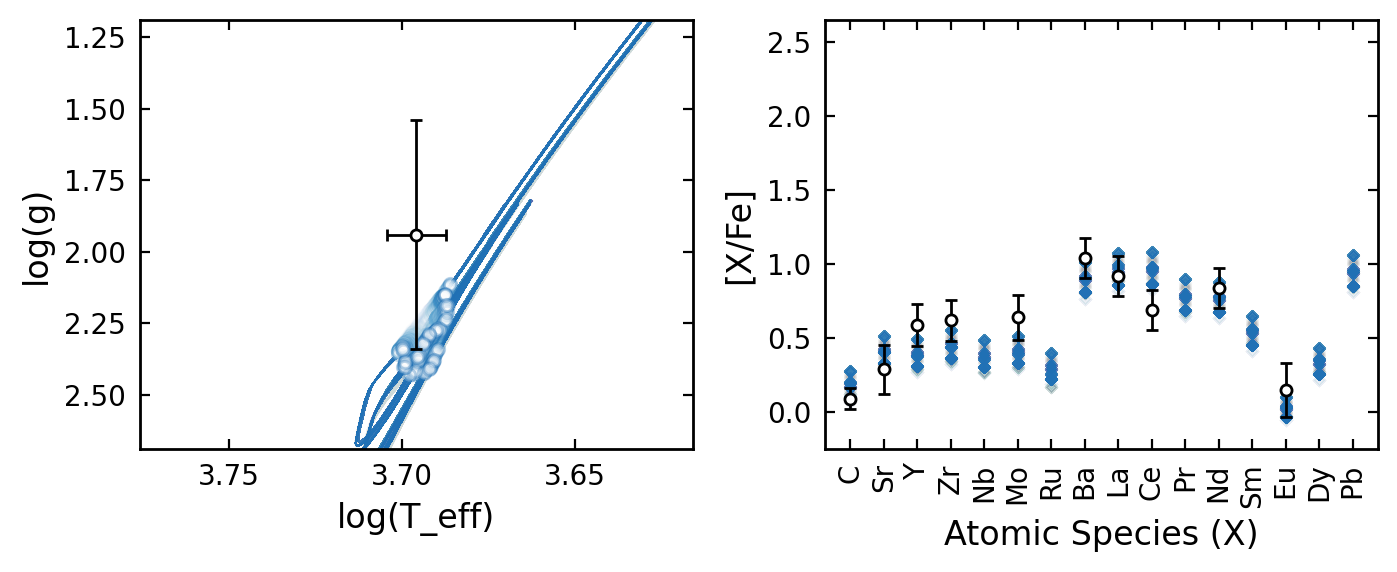

In [ ]:
#print('Plotting best models')

# display best models from run of: numba
#best_models = np.load('models_full_mass_limit_weights_stats/best_models_'+star_name+'_mass_limit_weights_stats.dat') 
#best_chis = np.load('chis_full_mass_limit_weights_stats/best_chis_'+star_name+'_mass_limit_weights_stats.dat') 

if len(models) != len(tracks):
    print('Error, len(models) != len(tracks)...')

# determine the number of models to plot based on probability threshold
num_mods_to_plot = 0
for i in np.arange(0,len(probs)):
    if probs[i] > 1e-17:
        num_mods_to_plot += 1

# create color array for plotting, gradient from color map
mod_colors = plt.cm.Blues(np.linspace(0,0.75,num_mods_to_plot))

mod_alphas = np.logspace(-1,-0.5,num_mods_to_plot)
#mod_sizes = np.linspace(8,32,len(best_models))

fig, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(7,3),dpi=200)
for i,mod_color,chi,prob,alpha in zip(np.arange(0,num_mods_to_plot),mod_colors,chis,probs,mod_alphas):
    
    chi_sq = str(round(chi,2)); #print(chi_sq)
    probab = str(round((prob),2)); #print(probab)

# find name of model track using unique and best model indices
    mod_metal = str(round(np.log10(float(str('0.'+unique[0][tracks[i][0]]))/0.0142),2))
    mod_AGB = str(unique[1][tracks[i][1]].split('p')[0]+'.'+unique[1][tracks[i][1]].split('p')[1]+'0')
    mod_m_i = str(unique[2][tracks[i][2]])
    mod_m_f = str(unique[3][tracks[i][3]])

    #track_name = str('[Fe/H]=' + mod_metal + r' M$_{AGB}$=' + mod_AGB + r' M$_i$=' + mod_m_i + r' M$_f$=' + mod_m_f)
    track_name = str('M_i=' + mod_m_i + ' M_f=' + mod_m_f + ' M_AGB=' + mod_AGB + ' [Fe/H]=' + mod_metal + ' chi2=' + chi_sq + ' log(P)=' + probab)

    # find best model point, extract logT, logg, and abundances
    mod_logT = MODEL[tracks[i][0],tracks[i][1],tracks[i][2],tracks[i][3],models[i],1]
    mod_logg = MODEL[tracks[i][0],tracks[i][1],tracks[i][2],tracks[i][3],models[i],2]
    mod_abunds = MODEL[tracks[i][0],tracks[i][1],tracks[i][2],tracks[i][3],models[i]][4:]
    #print(mod_abunds)
    # find whole track
    valid = VALID[tracks[i][0],tracks[i][1],tracks[i][2],tracks[i][3],:]
    mod_logT_track = MODEL[tracks[i][0],tracks[i][1],tracks[i][2],tracks[i][3],:,1][valid]
    mod_logg_track = MODEL[tracks[i][0],tracks[i][1],tracks[i][2],tracks[i][3],:,2][valid]

    # plot the whole model track, data points, and best model points along the track
    ax1.plot(mod_logT_track,mod_logg_track,zorder=0,color=mod_color,label=track_name, rasterized=True, lw=1.0, alpha=alpha/50)
    ax1.scatter(mod_logT,mod_logg,marker='o',facecolor='white',edgecolors=mod_color,s=20,zorder=1,alpha=alpha, rasterized=True)

    # plot model abundances
    ax2.scatter(obs_names_II, mod_abunds,zorder=1,marker='D',c=mod_color,s=8,alpha=alpha/50,rasterized=True)
    
# plot observational data - T_eff, logg on kiel diagram
ax1.errorbar(X_obs[1],X_obs[2], xerr=X_sig[1], yerr=X_sig[2], marker='o',capsize=2,elinewidth=1,
             markersize=4,color='black',markeredgecolor='black',markerfacecolor='white',zorder=2,label=star_name)
# plot observational abundances
for name,elem,err in zip(obs_names_II,obs_elems_II,obs_errrs_II):
    if (not name) or np.isnan(elem):
        continue
    if np.isnan(err):
        ax2.scatter([name],[elem],marker='v',s=18,edgecolor='black',facecolor='white',zorder=num_mods_to_plot+10)
    else:
        ax2.errorbar([name],[elem],yerr=[err],ls='',marker='o',markersize=4,elinewidth=1,capsize=2,
                     color='black',markeredgecolor='black',markerfacecolor='white',zorder=num_mods_to_plot+10)

ax1.set_xlabel('log(T_eff)')
ax1.set_ylabel('log(g)')
ax1.invert_xaxis()
ax1.invert_yaxis()
#ax1.legend(fontsize=4.5,loc=2,markerscale=0.65)

#ax1.set_xlim(4.0,3.4)
ax1.set_xlim(X_obs[1]+0.08,X_obs[1]-0.08)
#ax1.set_ylim(5.1,-1.1); 
#ax1.set_ylim(5.1,-0.6)
ax1.set_ylim(X_obs[2]+0.75,X_obs[2]-0.75)

# option to include K temperatures
#ax4 = ax1.twiny()
#ax4.scatter(10**X_obs[1],X_obs[2],s=0)
#ax4.set_xlabel(r'$\rm{T_{eff}}$')

ax2.set_xlabel('Atomic Species (X)')
ax2.tick_params(axis='x', rotation=90)
ax2.set_ylabel('[X/Fe]')
ax2.set_ylim(-0.25,2.65)

# option to add atomic numbers on axis corresponding to element
#ax3 = ax2.twiny()
#ax3.set_xlim(ax2.get_xlim())
#ax3.set_xticks(range(0,len(obs_names_II)))
#ax3.set_xticklabels(obs_elems_nums)
#ax3.tick_params(axis='x', rotation=90)
##ax3.plot(obs_elems_nums, obs_elems_nums)
##ax3 = ax2.secondary_xaxis('top', functions=(name_to_num, num_to_name))
#ax3.set_xlabel('Atomic Number (Z)')

plt.tight_layout()
#plt.savefig(star_name+'_mass_limit_weights.png',dpi=200,bbox_inches=None)
#print('End of Line')

In [77]:
def read_parameter_stats(star_name):
    """Read and display parameter statistics from file with error bars"""
    
    stats_dir = '/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/statistics_mass_limit_weights'
    stats_file = os.path.join(stats_dir, f'parameter_stats_{star_name}.txt')
    
    # Initialize dictionaries to store statistics
    stats = {
        'metallicity': {},
        'agb_mass': {},
        'initial_mass': {},
        'final_mass': {}
    }
    
    with open(stats_file, 'r') as f:
        lines = f.readlines()
        
        current_section = None
        reading_probs = False  # Flag to track when we're reading probability distributions
        
        for line in lines:
            line = line.strip()
            if not line or '=====' in line:
                continue
                
            if 'Metallicity' in line:
                current_section = 'metallicity'
                reading_probs = False
                #print(f'\n{line}')
            elif 'AGB Mass' in line:
                current_section = 'agb_mass'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Initial Mass' in line:
                current_section = 'initial_mass'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Final Mass' in line:
                current_section = 'final_mass'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Probability distribution:' in line:
                reading_probs = True
                continue
                
            if not reading_probs:
                if 'Mean:' in line:
                    stats[current_section]['mean'] = float(line.split(':')[1])
                    #print(line)
                elif 'Median:' in line:
                    stats[current_section]['median'] = float(line.split(':')[1])
                    #print(line)
                elif 'confidence' in line:
                    intervals = line.split('[')[1].split(']')[0].split(',')
                    stats[current_section]['conf_lower'] = float(intervals[0])
                    stats[current_section]['conf_upper'] = float(intervals[1])
                    
                    # Calculate uncertainties
                    if 'median' in stats[current_section]:
                        median = stats[current_section]['median']
                        stats[current_section]['err_lower'] = median - float(intervals[0])
                        stats[current_section]['err_upper'] = float(intervals[1]) - median
                        # Calculate median uncertainty as half the confidence interval
                        conf_range = float(intervals[1]) - float(intervals[0])
                        stats[current_section]['median_err'] = conf_range / 2
                    #print(line)
            else:
                # Only process probability distribution lines with valid number pairs
                if ':' in line:
                    try:
                        val, prob = line.split(':')
                        val = float(val)
                        prob = float(prob)
                        
                        if 'prob_dist' not in stats[current_section]:
                            stats[current_section]['prob_dist'] = {'values': [], 'probs': []}
                        stats[current_section]['prob_dist']['values'].append(val)
                        stats[current_section]['prob_dist']['probs'].append(prob)
                    except ValueError:
                        continue
                
    # Calculate standard errors for each parameter
    for param in stats:
        if 'prob_dist' in stats[param]:
            values = np.array(stats[param]['prob_dist']['values'])
            probs = np.array(stats[param]['prob_dist']['probs'])
            mean = stats[param]['mean']
            # Calculate standard error
            variance = np.sum(probs * (values - mean)**2)
            stats[param]['std_err'] = np.sqrt(variance)
    
    return stats

In [78]:
def plot_parameter_stats(star_name):
    """Plot parameter statistics read from file with probability distributions"""
    stats = read_parameter_stats(star_name)
    
    # Read the probability distributions from file
    stats_dir = '/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/statistics_mass_limit_weights'
    stats_file = os.path.join(stats_dir, f'parameter_stats_{star_name}.txt')
    if not os.path.exists(stats_file):
        print(f"Statistics file for {star_name} not found: {stats_file}")
        return None, stats
    
    # Initialize arrays for values and probabilities
    metal_vals, metal_probs = [], []
    agb_vals, agb_probs = [], []
    init_vals, init_probs = [], []
    final_vals, final_probs = [], []
    
    # Read probability distributions from file
    current_section = None
    with open(stats_file, 'r') as f:
        for line in f:
            if 'Probability distribution:' in line:
                continue
            if 'Metallicity' in line:
                current_section = 'metallicity'
                continue
            elif 'AGB Mass' in line:
                current_section = 'agb_mass'
                continue  
            elif 'Initial Mass' in line:
                current_section = 'initial_mass'
                continue
            elif 'Final Mass' in line:
                current_section = 'final_mass'
                continue
                
            # Parse probability distribution lines
            if ':' in line and not any(x in line for x in ['Mean:', 'Median:', 'confidence']):
                val, prob = line.strip().split(':')
                if current_section == 'metallicity':
                    metal_vals.append(float(val))
                    metal_probs.append(float(prob))
                elif current_section == 'agb_mass':
                    agb_vals.append(float(val))
                    agb_probs.append(float(prob))
                elif current_section == 'initial_mass':
                    init_vals.append(float(val))
                    init_probs.append(float(prob))
                elif current_section == 'final_mass':
                    final_vals.append(float(val))
                    final_probs.append(float(prob))
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))
    
    # Plot Metallicity distribution
    ax1.hist(metal_vals, weights=metal_probs, density=True, alpha=0.5)
    ax1.axvline(stats['metallicity']['mean'], color='r', ls='--', 
                label=f"Mean: {stats['metallicity']['mean']:.2f}")
    ax1.axvline(stats['metallicity']['median'], color='g', ls='--', 
                label=f"Median: {stats['metallicity']['median']:.2f}")
    ax1.axvspan(stats['metallicity']['conf_lower'], stats['metallicity']['conf_upper'],
                alpha=0.2, color='gray', label='68% conf.')
    ax1.set_xlabel('[Fe/H]')
    ax1.set_yscale('log')
    ax1.set_ylabel('Probability')
    ax1.legend(fontsize=8)
    ax1.set_title('Metallicity')
    
    # Plot AGB Mass distribution  
    ax2.hist(agb_vals, weights=agb_probs, density=True, alpha=0.5)
    ax2.axvline(stats['agb_mass']['mean'], color='r', ls='--', 
                label=f"Mean: {stats['agb_mass']['mean']:.2f}")
    ax2.axvline(stats['agb_mass']['median'], color='g', ls='--', 
                label=f"Median: {stats['agb_mass']['median']:.2f}")
    ax2.axvspan(stats['agb_mass']['conf_lower'], stats['agb_mass']['conf_upper'],
                alpha=0.2, color='gray', label='68% conf.')
    ax2.set_xlabel('M$_{AGB}$ (M$_{\odot}$)')
    ax2.set_yscale('log')
    ax2.set_ylabel('Probability')
    ax2.legend(fontsize=8)
    ax2.set_title('AGB Mass')
    
    # Plot Initial Mass distribution
    ax3.hist(init_vals, weights=init_probs, density=True, alpha=0.5)
    ax3.axvline(stats['initial_mass']['mean'], color='r', ls='--', 
                label=f"Mean: {stats['initial_mass']['mean']:.2f}")
    ax3.axvline(stats['initial_mass']['median'], color='g', ls='--', 
                label=f"Median: {stats['initial_mass']['median']:.2f}")
    ax3.axvspan(stats['initial_mass']['conf_lower'], stats['initial_mass']['conf_upper'],
                alpha=0.2, color='gray', label='68% conf.')
    ax3.set_xlabel('M$_{initial}$ (M$_{\odot}$)')
    ax3.set_yscale('log')
    ax3.set_ylabel('Probability')
    ax3.legend(fontsize=8)
    ax3.set_title('Initial Mass')
    
    # Plot Final Mass distribution
    ax4.hist(final_vals, weights=final_probs, density=True, alpha=0.5)
    ax4.axvline(stats['final_mass']['mean'], color='r', ls='--', 
                label=f"Mean: {stats['final_mass']['mean']:.2f}")
    ax4.axvline(stats['final_mass']['median'], color='g', ls='--', 
                label=f"Median: {stats['final_mass']['median']:.2f}")
    ax4.axvspan(stats['final_mass']['conf_lower'], stats['final_mass']['conf_upper'],
                alpha=0.2, color='gray', label='68% conf.')
    ax4.set_xlabel('M$_{final}$ (M$_{\odot}$)')
    ax4.set_yscale('log')
    ax4.set_ylabel('Probability')
    ax4.legend(fontsize=8)
    ax4.set_title('Final Mass')
    
    plt.suptitle(f'Parameter Statistics for {star_name}', y=1.02)
    plt.tight_layout()
    return fig, stats

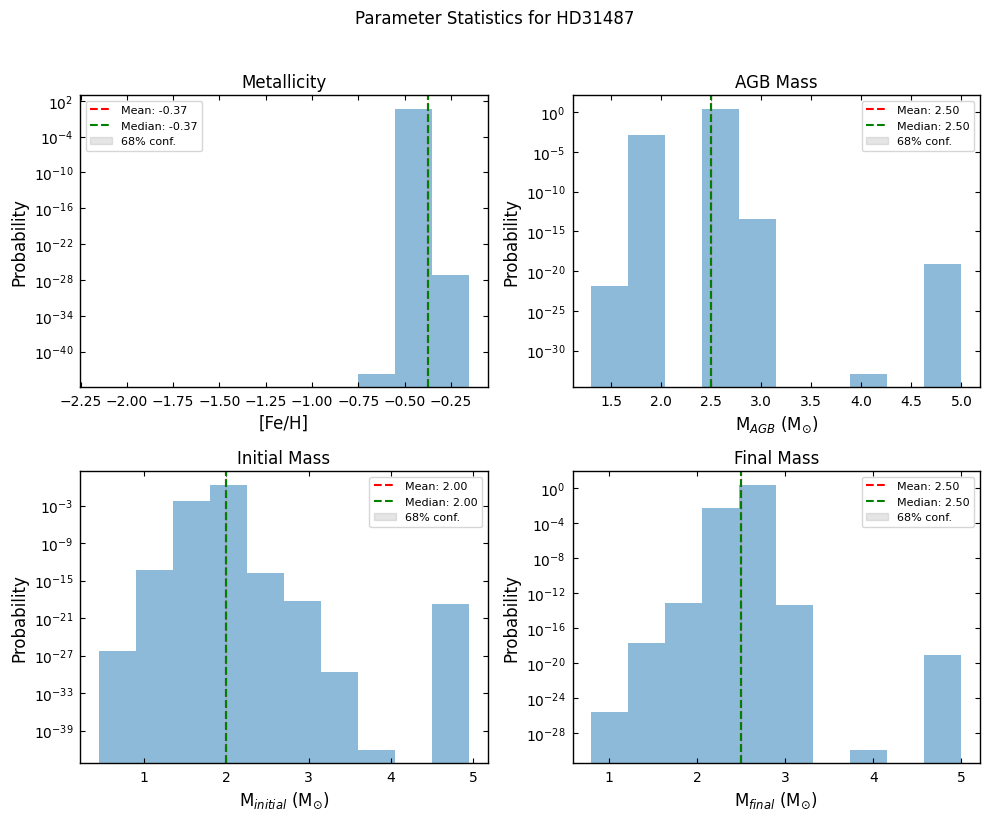

In [79]:
plot_parameter_stats(star_name);

In [132]:
# plot 2d histogram distributions of parameters minit and mfinal
def plot_2d_distributions(star_name, tracks):
    """Plot 2D distributions of initial vs final mass from best tracks"""
    #if not tracks:
    #    print("No best tracks provided.")
    #    return None
    
    # Extract parameters from best tracks indicies
    metalicitis = [metal_Z[track[0]] for track in tracks]
    agbs_masses = [agb_masses[track[1]] for track in tracks]
    init_masses = [initial_masses[track[2]] for track in tracks]
    fina_masses = [final_masses[track[3]] for track in tracks]
    
    fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(6, 5))
    
    h1 = ax1.hist2d(metalicitis, agbs_masses, bins=5, cmap='Blues', density=True)

    h2 = ax2.hist2d(agbs_masses, init_masses, bins=10, cmap='Blues', density=True)

    # Create 2D histogram
    h3 = ax3.hist2d(init_masses, fina_masses, bins=10, cmap='Blues', density=True)
    ax3.contour(h3[0], levels=5, cmap='Greys_r', linewidths=1, alpha=1.0,
               extent=[h3[1][0], h3[1][-1], h3[2][0], h3[2][-1]])

    ax4.hist2d(agbs_masses, fina_masses, bins=10, cmap='Blues', density=True)

    # Add color bar
    #cbar = plt.colorbar(h3[3], ax=ax3)
    #cbar.set_label('Density')
    
    # Plot 1:1 line
    min_mass = min(min(initial_masses), min(final_masses))
    max_mass = max(max(initial_masses), max(final_masses))
    ax3.plot([min_mass, max_mass], [min_mass, max_mass], color='red', ls='--', label='1:1 Line')

    ax3.set_xlim(min_mass, max_mass)
    ax3.set_ylim(min_mass, max_mass)
    ax3.set_xlabel('Initial Mass (M$_{\\odot}$)')
    ax3.set_ylabel('Final Mass (M$_{\\odot}$)')

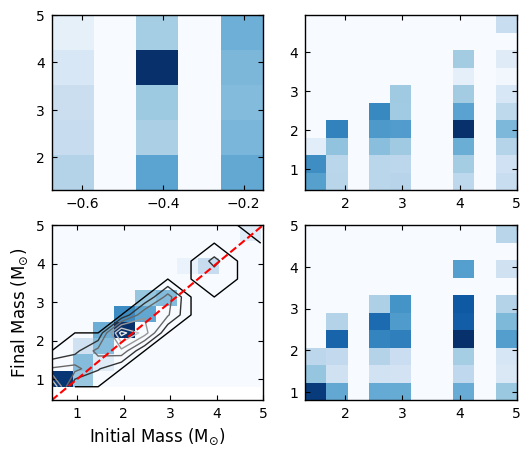

In [133]:
# plot 2d distribtuions of parameters minit and mfinal
plot_2d_distributions(star_name, tracks)